<a href="https://www.kaggle.com/code/shivanshcoding/learning-opencv?scriptVersionId=331247911" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip show opencv-python

Name: opencv-python
Version: 4.13.0.92
Summary: Wrapper package for OpenCV python bindings.
Home-page: https://github.com/opencv/opencv-python
Author: 
Author-email: 
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy
Required-by: dopamine_rl


In [6]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("/kaggle/input/datasets/bulentsiyah/opencv-samples-images/minions.jpg")

In [10]:
print(image.shape)
def printimg(img,rev=True):
    if rev:
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

(1280, 1280, 3)


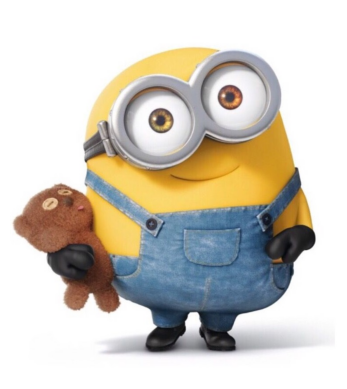

In [5]:
printimg(image)

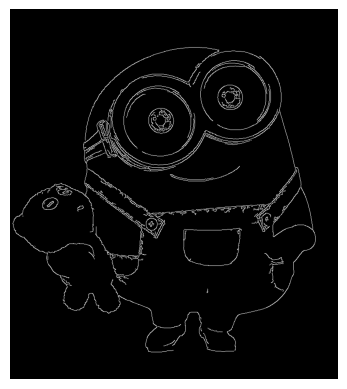

In [6]:
edge_image = cv2.Canny(image,100,200)
printimg(edge_image)

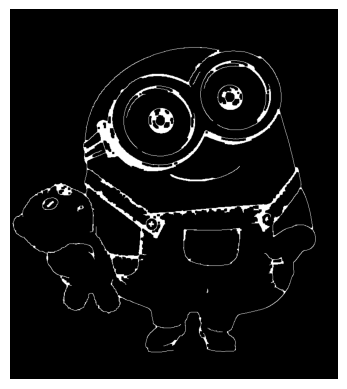

In [7]:
image_dilation = cv2.dilate(edge_image,np.ones((5,5),dtype = np.int8))
image_erosion = cv2.erode(image_dilation,np.ones((5,5),dtype = np.int8))
printimg(image_erosion)

### GRAYSCALE

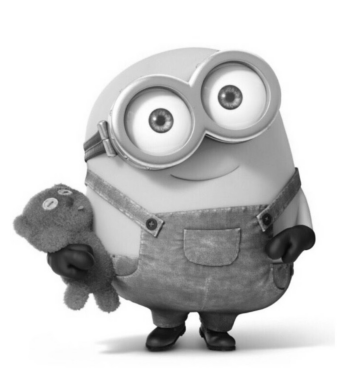

In [24]:
image_gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
printimg(image_gray)

### THRESHOLDING

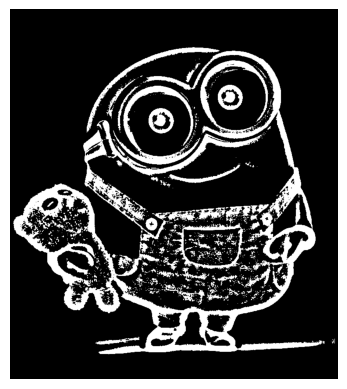

In [51]:
a_thresh_image = cv2.adaptiveThreshold(image_gray,255,
                                           cv2.ADAPTIVE_THRESH_MEAN_C,
                                           cv2.THRESH_BINARY_INV,31,6)
printimg(a_thresh_image)

250.0


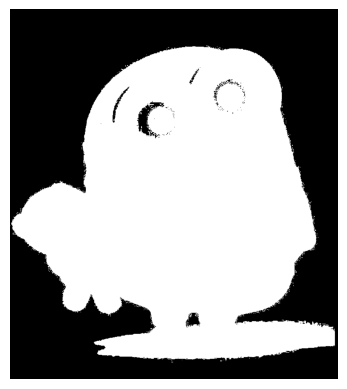

In [53]:
th,thresh_image = cv2.threshold(image_gray,250,255,cv2.THRESH_BINARY_INV)
print(th)
printimg(thresh_image)

### CONTOURS

In [61]:
cont, hier = cv2.findContours(a_thresh_image,cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)

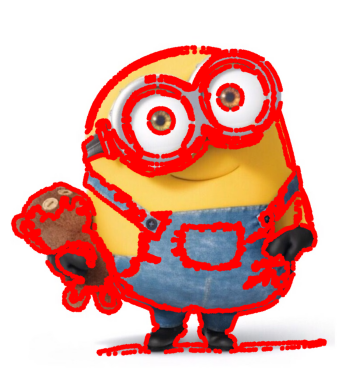

In [62]:
a = image.copy()
for cnt in cont:
    if cv2.contourArea(cnt) > 2000:
        cv2.drawContours(a, cnt, -1, (0,0,255),10)

printimg(a)

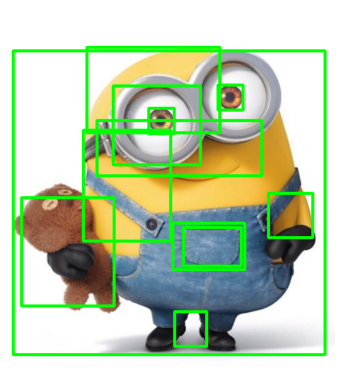

In [63]:
b = image.copy()
for cnt in cont:
    if cv2.contourArea(cnt) > 2000:
        # cv2.drawContours(a, cnt, -1, (0,0,255),10)
        x1,y1,w,h = cv2.boundingRect(cnt)
        cv2.rectangle(b,(x1,y1),(x1+w,y1+h),(0,255,0),5)

printimg(b)

### DRAWING

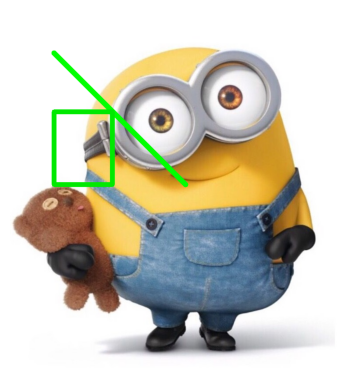

In [8]:
cv2.line(image,(100,100),(400,400),(0,255,0),12)
cv2.rectangle(image,(100,234),(233,400),(0,233,0),10)
printimg(image)

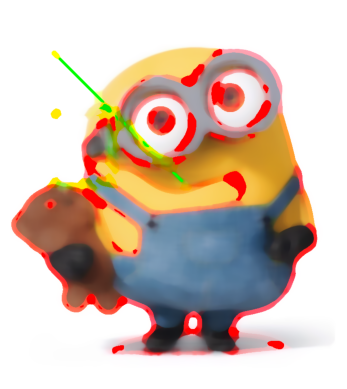

In [14]:
k_size = 9
# blur_image = cv2.GaussianBlur(image,(k_size,k_size),5)
# blur_image = cv2.blur(image,(k_size,k_size),5)
blur_image = cv2.medianBlur(image,k_size*3)

blur_image_rgb = cv2.cvtColor(blur_image, cv2.COLOR_BGR2RGB)

plt.imshow(blur_image_rgb)
plt.axis('off')
plt.show()

In [15]:
cropped_image = image[150:500,200:620]
print(cropped_image.shape)

(350, 420, 3)


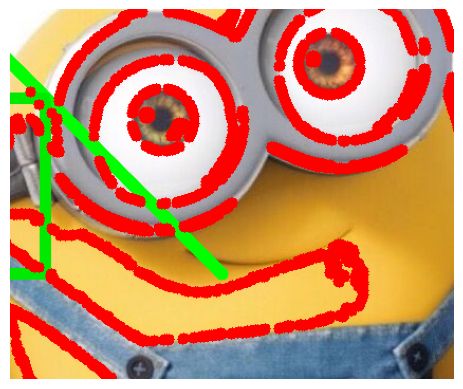

In [16]:
cropped_image_rgb = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2RGB)

plt.imshow(cropped_image_rgb)
plt.axis('off')
plt.show()

In [17]:
resized_image =  cv2.resize(image,(2000,1600))
print(resized_image.shape)

(1600, 2000, 3)


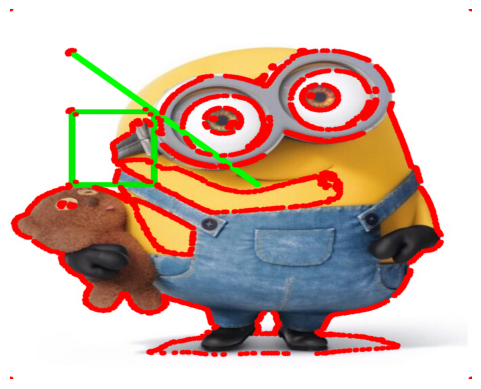

In [18]:
resized_image_rgb = cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB)

plt.imshow(resized_image_rgb)
plt.axis('off')
plt.show()

In [20]:
import os
video_path = "/kaggle/input/datasets/bulentsiyah/opencv-samples-images/Background_Subtraction_Tutorial_frame.mp4"
print("File exists:", os.path.exists(video_path))
from IPython.display import clear_output, display

File exists: True


In [21]:
video = cv2.VideoCapture(video_path)

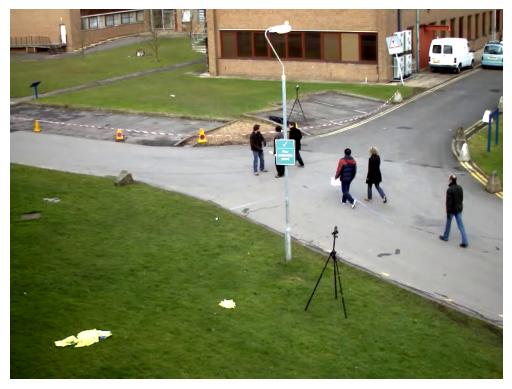

In [22]:
try:
    while video.isOpened():
        ret, frame = video.read()
        if not ret:
            break
            
        # OpenCV reads BGR, Matplotlib needs RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Clear the previous frame to animate the video inline
        clear_output(wait=True)
        
        # Plot the current frame
        plt.imshow(frame_rgb)
        plt.axis('off')
        plt.show()
        
except KeyboardInterrupt:
    # Allows you to safely stop the video playback by clicking the stop button in Kaggle
    print("Stream stopped by user.")

finally:
    video.release()

### DETECTING COLOUR

In [78]:
def get_limits(color):
    c = np.uint8([[color]])
    hsvC = cv2.cvtColor(c, cv2.COLOR_BGR2HSV)
    
    hue = int(hsvC[0][0][0])
    
    lower_hue = max(0, hue - 10)
    upper_hue = min(179, hue + 10)
    
    lowerlimit = np.array([lower_hue, 100, 100], dtype=np.uint8)
    upperlimit = np.array([upper_hue, 255, 255], dtype=np.uint8)

    return lowerlimit, upperlimit

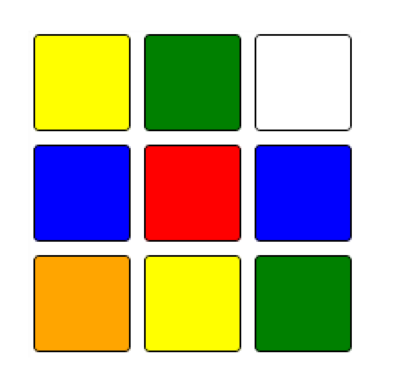

In [79]:
image = cv2.imread("/kaggle/input/datasets/shivanshcoding/rag-dataset-with-evaluation/cube-face.png")
printimg(image)

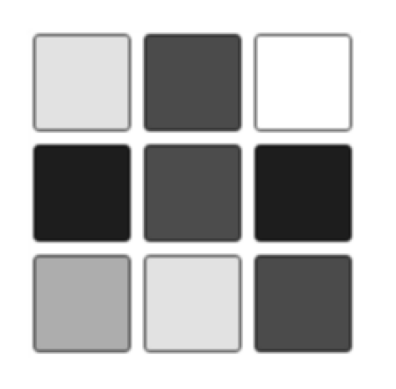

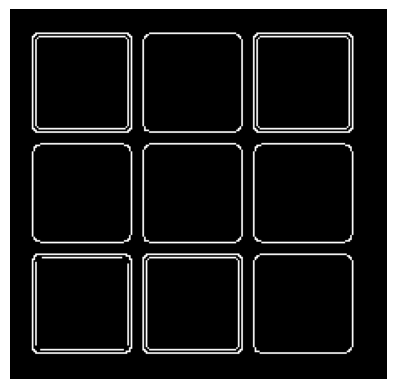

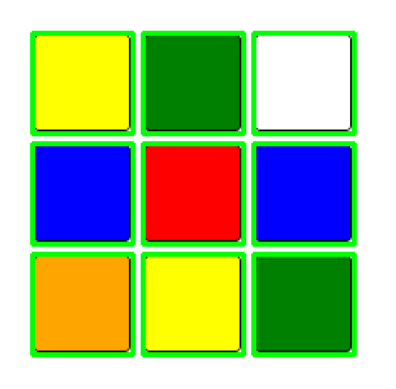

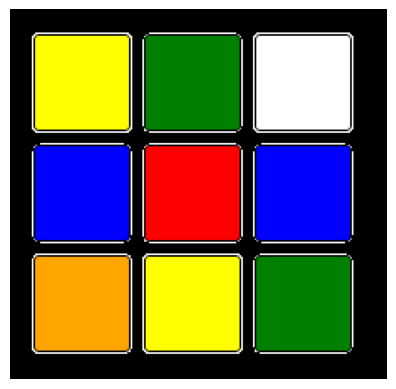

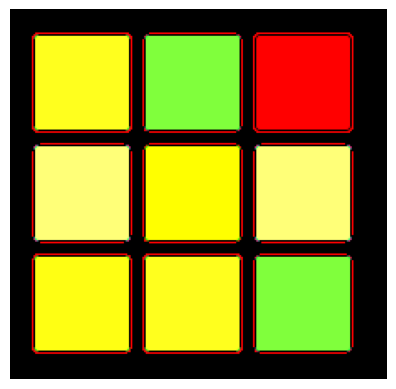

In [80]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 2. Use Threshold + Canny Edges to find the borders of the stickers/cube
blurred = cv2.GaussianBlur(gray, (3, 3), 0)
printimg(blurred)
edges = cv2.Canny(blurred, 50, 150)
printimg(edges)


# 3. Find all outer boundaries
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

b = image.copy()
for cnt in contours:
    if cv2.contourArea(cnt) > 2000:
        # cv2.drawContours(a, cnt, -1, (0,0,255),10)
        x1,y1,w,h = cv2.boundingRect(cnt)
        cv2.rectangle(b,(x1,y1),(x1+w,y1+h),(0,255,0),2)

printimg(b)

# 4. Create a blank black canvas of the exact same size
mask_background = np.zeros_like(gray)

for cnt in contours:
    area = cv2.contourArea(cnt)
    # Adjust this range depending on how large your cube is in the frame
    if 2000 < area < 5000: 
        # Check if the shape is roughly a square (Aspect Ratio close to 1.0)
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(w) / h
        
        if 0.8 <= aspect_ratio <= 1.2:
            # Draw the detected cube area as pure white on our black canvas
            cv2.drawContours(mask_background, [cnt], -1, 255, -1)

# 5. Extract ONLY the cube from the original image, leaving the background pitch black
clean_image = cv2.bitwise_and(image, image, mask=mask_background)
printimg(clean_image)

# 6. Convert to HSV *after* cleaning the background
hsvImage = cv2.cvtColor(clean_image, cv2.COLOR_BGR2HSV)
printimg(hsvImage)

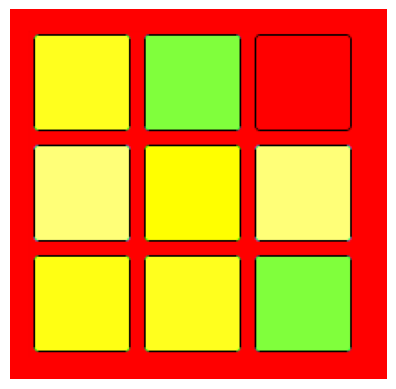

In [12]:
hsvImage = cv2.cvtColor(image,cv2.COLOR_BGR2HSV)
printimg(hsvImage)

In [83]:
red    = [0, 0, 255]     # Pure Red
orange = [0, 165, 255]   # Orange (Mix of Red and some Green)
green  = [0, 255, 0]     # Pure Green
blue   = [255, 0, 0]     # Pure Blue
white  = [255, 255, 255] # Pure White
yellow = [0,255,255]     # Yellow in BGR

color_map = {
    "red":["F",[0, 0, 255]] ,
    "orange":["B",[0, 165, 255]],   # Orange (Mix of Red and some Green)
    "green": ["R",[0, 255, 0]],     # Pure Green
    "blue" : ["L",[255, 0, 0]],
    "white": ["U",[255,255,255]],
    "yellow" :["D",[0, 255, 255]]
}

low_red, up_red       = get_limits(red)
low_orange, up_orange = get_limits(orange)
low_green, up_green   = get_limits(green)
low_blue, up_blue     = get_limits(blue)
# low_white, up_white   = get_limits(white)
low_yellow,up_yellow = get_limits(yellow)

# 2. Hardcode WHITE (Ignore Hue, look for low Saturation + high Brightness)
low_white = np.array([0, 0, 180], dtype=np.uint8)
up_white  = np.array([179, 50, 255], dtype=np.uint8)

# 3. Hardcode RED (Look for high Saturation + low/high Hue extremes)
# Since red wraps around 0 and 180, a safe tight range for a true red sticker is:
# low_red   = np.array([165, 100, 100], dtype=np.uint8)
# up_red    = np.array([179, 255, 255], dtype=np.uint8)

color_limit_dict = {
    "F": [red, low_red, up_red],
    "B": [orange, low_orange, up_orange],
    "R": [green, low_green, up_green],
    "L": [blue, low_blue, up_blue],
    "U": [white, low_white, up_white],
    "D": [yellow, low_yellow, up_yellow]
}

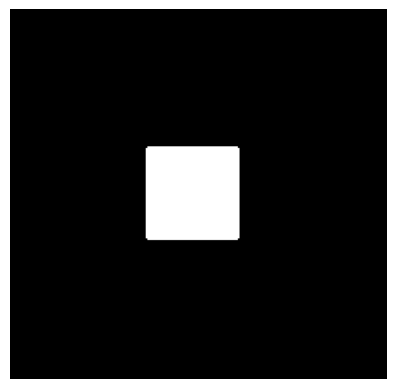

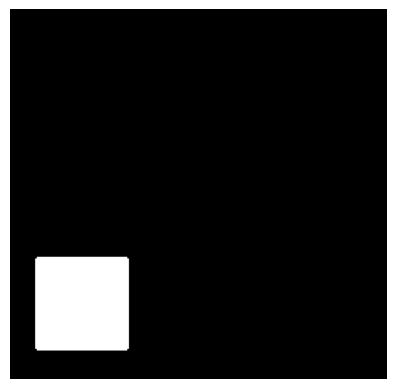

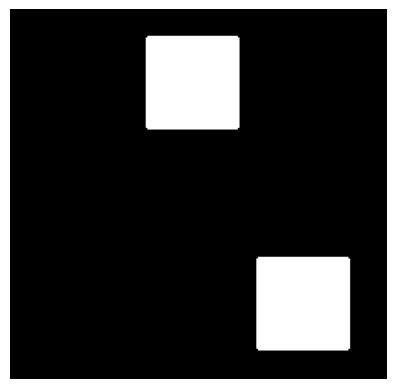

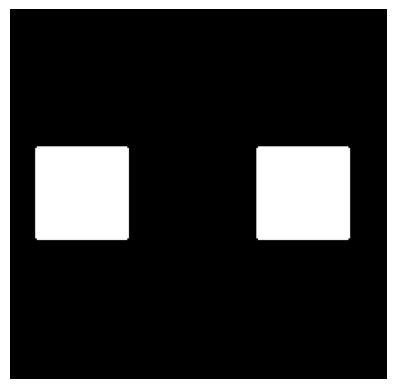

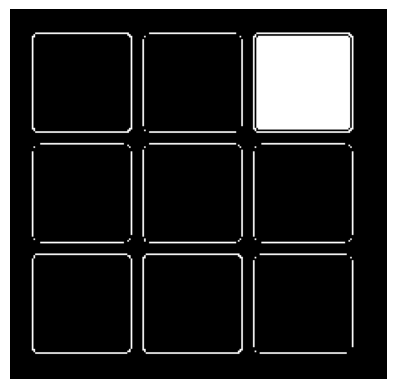

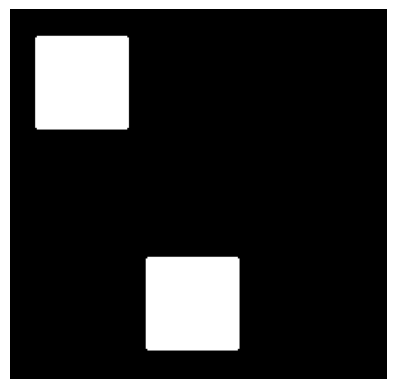

In [84]:
masks_dict = {}

for face, arr in color_limit_dict.items():
    mask = cv2.inRange(hsvImage,arr[1],arr[2])
    
    masks_dict[face] = mask
    printimg(mask)

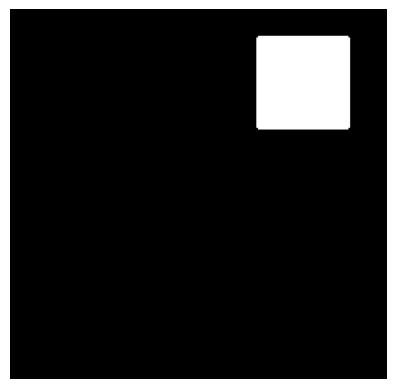

In [94]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate your raw white mask (using your dictionary or limits)
mask_white = cv2.inRange(hsvImage, low_white, up_white)

# 2. Clean up noise using Morphological Opening (Erosion followed by Dilation)
# This completely erases thin outer edges and small random specs
kernel = np.ones((3, 3), np.uint8)
cleaned_white_mask = cv2.morphologyEx(mask_white, cv2.MORPH_OPEN, kernel, iterations=1)

# 3. Find contours on this cleaned mask
contours, _ = cv2.findContours(cleaned_white_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 4. Create a final, polished mask where we only draw real square stickers
final_white_mask = np.zeros_like(cleaned_white_mask)

for cnt in contours:
    area = cv2.contourArea(cnt)
    
    # Adjust this area threshold based on your image size
    # True stickers will have a solid area, whereas edge artifacts are usually tiny
    if area > 2000: 
        # Get the bounding box to check the aspect ratio
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = float(w) / h
        
        # A perfect sticker is a square (aspect ratio = 1.0)
        # This eliminates long thin edge lines or random shapes
        if 0.85 <= aspect_ratio <= 1.15:
            # Draw ONLY the valid square stickers onto our final mask
            cv2.drawContours(final_white_mask, [cnt], -1, 255, -1)

# Save the polished mask back into your dictionary
masks_dict[color_map["white"][0]] = final_white_mask

# Display it to verify the outer edges are completely gone!
printimg(final_white_mask)

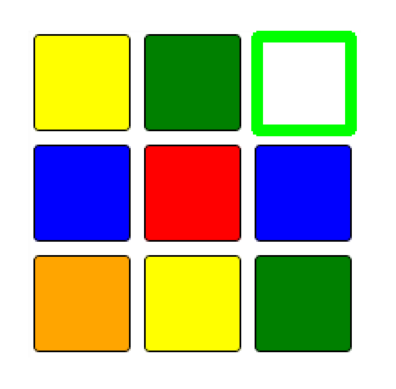

In [87]:
from PIL import Image 
a = image.copy()
mask_ = Image.fromarray(final_white_mask)
bbox = mask_.getbbox()
if bbox is not None:
    x1, y1, x2, y2 = bbox
    a = cv2.rectangle(a,(x1,y1),(x2,y2),(0,255,0),5)
    printimg(a)

In [95]:
all_stickers = []

for label, mask in masks_dict.items():
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for cnt in contours:
        if cv2.contourArea(cnt) > 500: 
            M = cv2.moments(cnt)
            if M["m00"] != 0:
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
                
                # Keep track of where this color sticker is located
                all_stickers.append((cX, cY, label))

In [96]:
print(all_stickers)

[(108, 109, 'F'), (42, 175, 'B'), (174, 175, 'R'), (108, 43, 'R'), (174, 109, 'L'), (42, 109, 'L'), (174, 43, 'U'), (108, 175, 'D'), (42, 43, 'D')]


In [97]:
all_stickers.sort(key=lambda item: item[1])

grid = [['' for _ in range(3)] for _ in range(3)]

for row_idx in range(3):
    row_stickers = all_stickers[row_idx * 3 : (row_idx + 1) * 3]
    
    row_stickers.sort(key=lambda item: item[0])
    
    for col_idx in range(3):
        grid[row_idx][col_idx] = row_stickers[col_idx][2]

Generated 3x3 Grid Matrix:
[['D' 'R' 'U']
 ['L' 'F' 'L']
 ['B' 'D' 'R']]


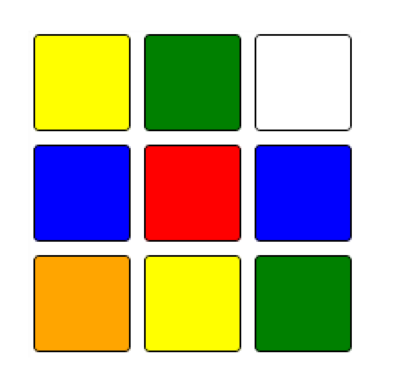

In [99]:
cube_face = np.array(grid)

print("Generated 3x3 Grid Matrix:")
print(cube_face)
printimg(image)

In [111]:
def isolate_stickers(image):
    """
    Finds the square stickers in the image and turns the entire background pure black.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 50, 150)
    
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Create a pure black canvas the exact same size as the image
    black_canvas = np.zeros_like(image)
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if 300 < area < 40000:
            x, y, w, h = cv2.boundingRect(cnt)
            aspect_ratio = float(w) / h
            
            # If it's a square, draw it onto the black canvas in pure white
            if 0.80 <= aspect_ratio <= 1.25:
                cv2.drawContours(black_canvas, [cnt], -1, (255, 255, 255), thickness=cv2.FILLED)
                
    # Bitwise AND merges the real colors back into the white squares on our canvas.
    # Everything else remains pitch black.
    clean_image = cv2.bitwise_and(image, black_canvas)
    return clean_image

In [129]:
def get_strict_limits(bgr_color):
    """
    Uses your original strict limits, but safely prevents crashes.
    """
    c = np.uint8([[bgr_color]])
    hsv_c = cv2.cvtColor(c, cv2.COLOR_BGR2HSV)
    
    hue = int(hsv_c[0][0][0])
    sat = int(hsv_c[0][0][1])
    val = int(hsv_c[0][0][2])
    
    # REQUIRED: White has no Hue. We must handle it manually.
    if sat < 40 and val > 200:
        return np.array([0, 0, 150], dtype=np.uint8), np.array([179, 60, 255], dtype=np.uint8)

    # Your original exact strict limits logic safely clamped
    lower_hue = max(0, hue - 10)
    upper_hue = min(179, hue + 10)
    
    lower_limit = np.array([lower_hue, 100, 100], dtype=np.uint8)
    upper_limit = np.array([upper_hue, 255, 255], dtype=np.uint8)
    
    return lower_limit, upper_limit

In [130]:
def process_cube_face_clean(image, face_bgr_map):
    if image is None:
        raise ValueError("Input image is empty.")
        
    # --- STEP 1: PREPROCESS TO BLACK BACKGROUND ---
    clean_image = isolate_stickers(image)
    printimg(clean_image)
    hsv_image = cv2.cvtColor(clean_image, cv2.COLOR_BGR2HSV)
    printimg(hsv_image)
    
    all_detected_stickers = []
    
    # --- STEP 2: DETECT COLORS ---
    for face_label, bgr_color in face_bgr_map.items():
        low_limit, up_limit = get_strict_limits(bgr_color)
        raw_mask = cv2.inRange(hsv_image, low_limit, up_limit)
        
        kernel = np.ones((3, 3), np.uint8)
        clean_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel, iterations=1)
        
        # Because the background is black, contours are much cleaner now
        contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        for cnt in contours:
            if cv2.contourArea(cnt) > 1000: 
                M = cv2.moments(cnt)
                if M["m00"] != 0:
                    cX = int(M["m10"] / M["m00"])
                    cY = int(M["m01"] / M["m00"])
                    all_detected_stickers.append((cX, cY, face_label))

    print(all_detected_stickers)
    if len(all_detected_stickers) != 9:
        print(f"⚠️ Error: Only found {len(all_detected_stickers)} stickers. Grid cannot be built.")
        return None

    # --- STEP 4: BUILD GRID ---
    all_detected_stickers.sort(key=lambda item: item[1])
    grid = [['' for _ in range(3)] for _ in range(3)]
    
    for row_idx in range(3):
        row_stickers = all_detected_stickers[row_idx*3 : (row_idx+1)*3]
        row_stickers.sort(key=lambda item: item[0])
        for col_idx in range(3):
            grid[row_idx][col_idx] = row_stickers[col_idx][2]
            
    return np.array(grid)

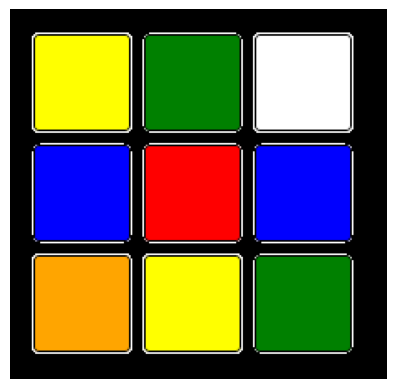

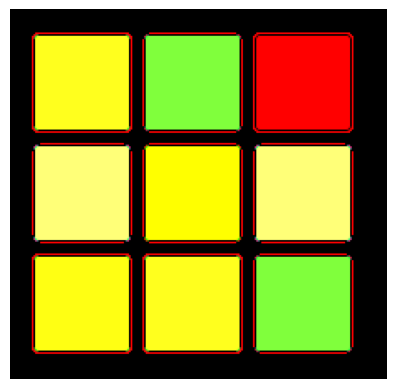

[(108, 109, 'F'), (42, 175, 'B'), (174, 175, 'R'), (108, 43, 'R'), (174, 109, 'L'), (42, 109, 'L'), (174, 43, 'U'), (108, 175, 'D'), (42, 43, 'D')]
[['D' 'R' 'U']
 ['L' 'F' 'L']
 ['B' 'D' 'R']]


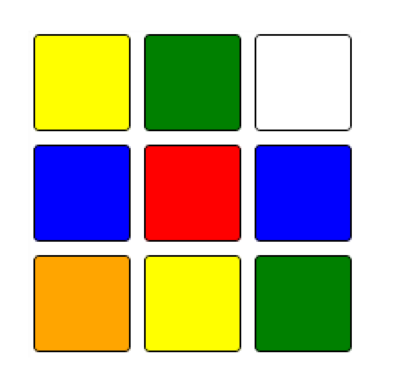

In [131]:
# Your clean production dictionary layout
app_color_map = {
    "F": [0, 0, 255],       # Front Face BGR
    "B": [0, 165, 255],     # Back Face BGR
    "R": [0, 255, 0],       # Right Face BGR
    "L": [255, 0, 0],       # Left Face BGR
    "U": [255, 255, 255],   # Up Face BGR
    "D": [0, 255, 255]      # Down Face BGR
}

color_map = {
    "red":["F",[0, 0, 255]] ,
    "orange":["B",[0, 165, 255]],   # Orange (Mix of Red and some Green)
    "green": ["R",[0, 255, 0]],     # Pure Green
    "blue" : ["L",[255, 0, 0]],
    "white": ["U",[255,255,255]],
    "yellow" :["D",[0, 255, 255]]
}


result_grid = process_cube_face_clean(image, app_color_map)

print(result_grid)
printimg(image)

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def resize_image(image, width=600):
    h, w = image.shape[:2]
    ratio = width / float(w)
    return cv2.resize(image, (width, int(h * ratio)))

def is_valid_cube_face_auto(image):
    if image is None:
        return False, None
        
    img_resized = resize_image(image, width=600)
    display_image = img_resized.copy()
    
    lab = cv2.cvtColor(img_resized, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
    cl = clahe.apply(l)
    
    merged = cv2.merge((cl, a, b))
    enhanced_bgr = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)
    gray = cv2.cvtColor(enhanced_bgr, cv2.COLOR_BGR2GRAY)
    
    blurred = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)
    
    edges = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                  cv2.THRESH_BINARY_INV, 21, 5)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
    
    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    candidates = []
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        
        if 400 < area < 30000:
            rect = cv2.minAreaRect(cnt)
            w, h = rect[1]
            if w == 0 or h == 0: continue
            
            aspect_ratio = max(w, h) / min(w, h)
            
            hull = cv2.convexHull(cnt)
            hull_area = cv2.contourArea(hull)
            if hull_area == 0: continue
            
            solidity = float(area) / hull_area
            
            if solidity > 0.65 and aspect_ratio < 1.8:
                candidates.append({"contour": cnt, "area": area})

    cv2.putText(display_image, f"Squares counted: {len(candidates)}", (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    if len(candidates) < 9:
        cv2.drawContours(display_image, [c["contour"] for c in candidates], -1, (0, 0, 255), 2)
        return False, display_image

    candidates.sort(key=lambda x: x["area"])
    valid_face_found = False
    best_9_contours = []
    
    for i in range(len(candidates) - 8):
        window = candidates[i : i+9]
        min_area = window[0]["area"]
        max_area = window[-1]["area"]
        
        if max_area / min_area < 4.0: 
            valid_face_found = True
            best_9_contours = [item["contour"] for item in window]
            break

    if valid_face_found:
        cv2.drawContours(display_image, best_9_contours, -1, (0, 255, 0), 3)
        cv2.putText(display_image, "FACE LOCKED", (10, 60), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        return True, display_image
    else:
        cv2.drawContours(display_image, [c["contour"] for c in candidates], -1, (0, 165, 255), 2)
        cv2.putText(display_image, "Failed: Grouping Check", (10, 60), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 165, 255), 2)
        return False, display_image

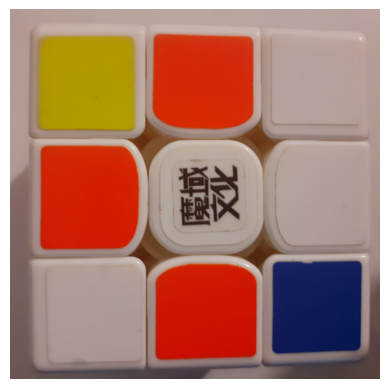

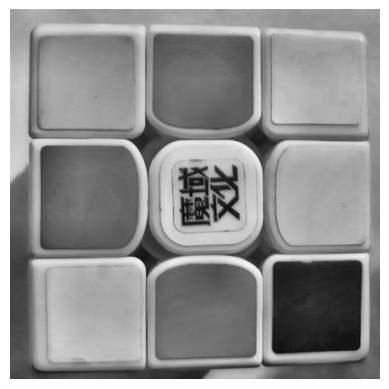

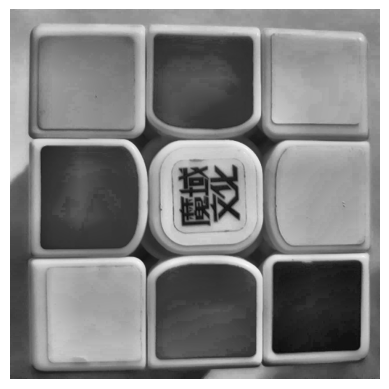

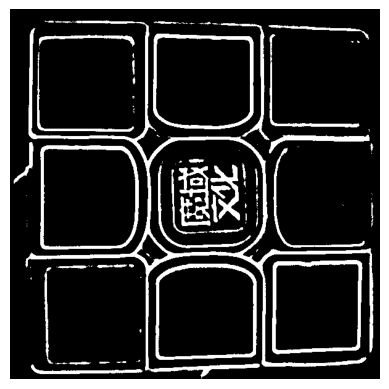

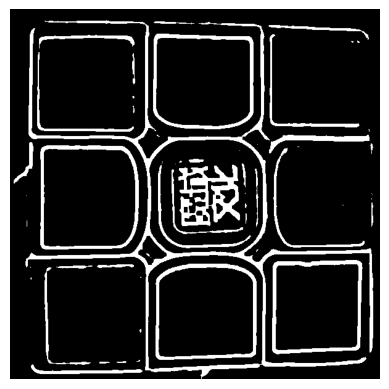

❌ REJECTED: WhatsApp Image 2021-02-16 at 7.59.05 PM (2).jpeg (Bad angle/lighting or missing squares)


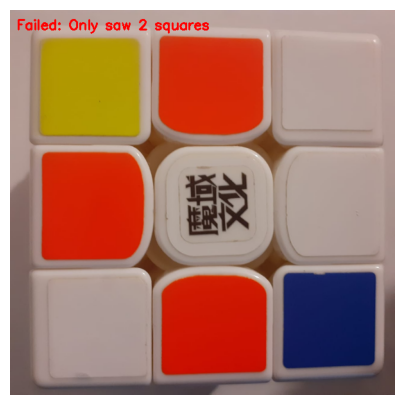

----------------------------------------


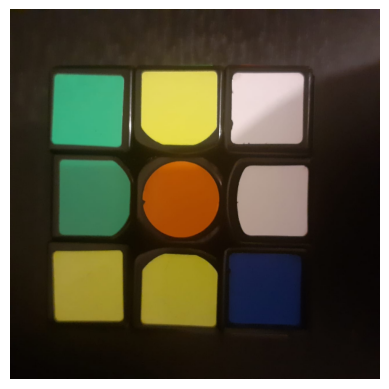

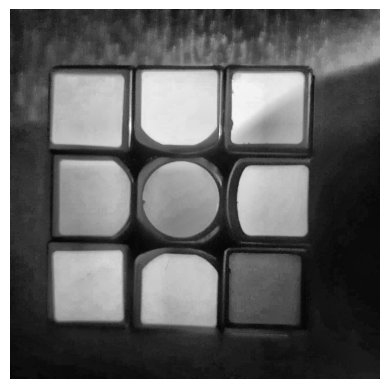

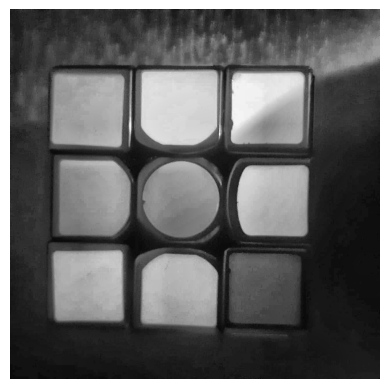

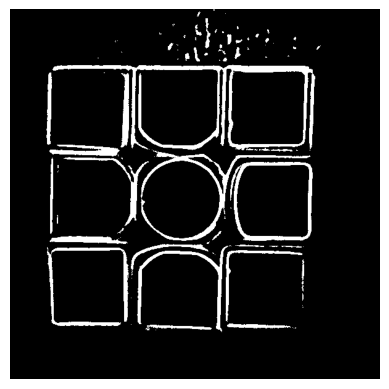

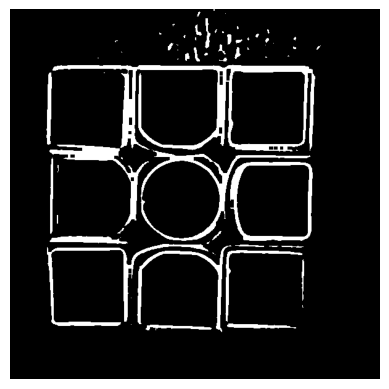

❌ REJECTED: WhatsApp Image 2021-02-16 at 7.57.25 PM.jpeg (Bad angle/lighting or missing squares)


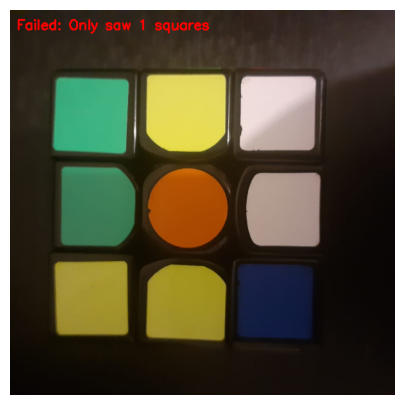

----------------------------------------


In [37]:
import glob
import os

dataset_path = "/kaggle/input/datasets/sebastianponce/rubiks-cubes-faces/*.jpeg"
image_files = glob.glob(dataset_path)

for img_path in image_files[:2]: # Test 10 images
    image = cv2.imread(img_path)
    if image is None: continue
        
    # Run our Gatekeeper
    is_valid, debug_img = is_valid_cube_face(image)
    
    filename = os.path.basename(img_path)
    if is_valid:
        print(f"✅ ACCEPTED: {filename}")
    else:
        print(f"❌ REJECTED: {filename} (Bad angle/lighting or missing squares)")
    
    # Plot to see what the algorithm saw
    plt.figure(figsize=(5, 5))
    plt.imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    print("-" * 40)